# Q1:

## 1. Data Preparation & Tokenization:

In [167]:
import os
import sentencepiece as spm
from torch.utils.data import Dataset, DataLoader
import torch

# 1.1 Reading parallel corpus
def read_parallel(src_path, tgt_path):
    with open(src_path, 'r', encoding='utf-8') as f_src, \
         open(tgt_path, 'r', encoding='utf-8') as f_tgt:
        src_lines = [line.strip() for line in f_src]
        tgt_lines = [line.strip() for line in f_tgt]
    assert len(src_lines) == len(tgt_lines), "Alignment mismatch"  
    return src_lines, tgt_lines


train_en, train_ur = read_parallel('/kaggle/input/quran-dataset/train.en', '/kaggle/input/quran-dataset/train.ur')
dev_en, dev_ur     = read_parallel('/kaggle/input/quran-dataset/dev.en',   '/kaggle/input/quran-dataset/dev.ur')
test_en, test_ur   = read_parallel('/kaggle/input/quran-dataset/test.en',  '/kaggle/input/quran-dataset/test.ur')


# 1.2 SentencePiece BPE model
spm.SentencePieceTrainer.Train('--input=/kaggle/input/quran-dataset/train.en --model_prefix=spm_en --vocab_size=8200 --model_type=bpe --num_threads=16')  
spm.SentencePieceTrainer.Train('--input=/kaggle/input/quran-dataset/train.ur --model_prefix=spm_ur --vocab_size=8200 --model_type=bpe --num_threads=16') 
sp_en = spm.SentencePieceProcessor(model_file='spm_en.model')
sp_ur = spm.SentencePieceProcessor(model_file='spm_ur.model')


# 1.3 Dataset class
class TranslationDataset(Dataset):
    def __init__(self, src_lines, tgt_lines, sp_src, sp_tgt, max_len=128):
        self.src = src_lines; self.tgt = tgt_lines
        self.sp_src = sp_src; self.sp_tgt = sp_tgt
        self.max_len = max_len

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        src_ids = self.sp_src.encode(self.src[idx])[:self.max_len-2]
        tgt_ids = self.sp_tgt.encode(self.tgt[idx])[:self.max_len-2]
        return {
            'src': torch.tensor([1] + src_ids + [2]),  # 1=SOS, 2=EOS
            'tgt': torch.tensor([1] + tgt_ids + [2])
        }

train_ds = TranslationDataset(train_en, train_ur, sp_en, sp_ur)
dev_ds   = TranslationDataset(dev_en,   dev_ur,   sp_en, sp_ur)
test_ds  = TranslationDataset(test_en,  test_ur,  sp_en, sp_ur)

def collate_fn(batch):
    src = [b['src'] for b in batch]
    tgt = [b['tgt'] for b in batch]
    src = torch.nn.utils.rnn.pad_sequence(src, padding_value=0, batch_first=True)
    tgt = torch.nn.utils.rnn.pad_sequence(tgt, padding_value=0, batch_first=True)
    return src, tgt

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)  
dev_loader   = DataLoader(dev_ds,   batch_size=64, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=collate_fn)


In [168]:
len(train_loader)

94

## 2.1 Transformer:

In [169]:
import math
from torch import nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1)]
        return x


class TransformerMT(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=512, nhead=8,
                 num_layers=6, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.src_tok = nn.Embedding(src_vocab, d_model)
        self.tgt_tok = nn.Embedding(tgt_vocab, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model, nhead, num_layers, num_layers,
            dim_feedforward, dropout
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab)

    def forward(self, src, tgt):
        
        # src: (batch, src_len), tgt: (batch, tgt_len)
        # embedding + positional encoding, then transpose to (seq_len, batch, d_model)
        
        src_emb = self.pos_enc(self.src_tok(src).transpose(0, 1))
        tgt_emb = self.pos_enc(self.tgt_tok(tgt).transpose(0, 1))

        # building causal mask for tgt
        tgt_seq_len = tgt_emb.size(0)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_seq_len,
            device=src.device,
            dtype=tgt_emb.dtype
        )

        out = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask
        )
        
        return self.fc_out(out).transpose(0, 1)


## 2.2 LSTM with Bahdanau Attention:

In [180]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from tqdm import trange, tqdm
import numpy as np
import sacrebleu
from rouge import Rouge


class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim):
        super().__init__()
        
        self.W1 = nn.Linear(enc_dim, enc_dim)  
        self.W2 = nn.Linear(dec_dim, enc_dim)  
        self.V  = nn.Linear(enc_dim, 1)

    def forward(self, dec_hidden, enc_outputs):
       
        proj_enc = self.W1(enc_outputs)                    
        proj_dec = self.W2(dec_hidden).unsqueeze(1)       
        score    = self.V(torch.tanh(proj_enc + proj_dec)) 
        weights  = torch.softmax(score, dim=1)             
        context  = (weights * enc_outputs).sum(dim=1)      
        return context, weights


class Seq2SeqLSTM(nn.Module):
    def __init__(self, src_vocab, tgt_vocab,
                 embed_size=256, hidden_size=512, num_layers=2, dropout=0.1):
        super().__init__()
        self.embedding_src = nn.Embedding(src_vocab, embed_size)
        self.embedding_tgt = nn.Embedding(tgt_vocab, embed_size)

        # bidirectional encoder
        self.encoder = nn.LSTM(
            embed_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        enc_dim = hidden_size * 2

        # project encoder's final state into decoder's hidden_size
        self.init_hidden = nn.Linear(enc_dim, hidden_size)
        self.init_cell   = nn.Linear(enc_dim, hidden_size)

        # attention now knows both dims
        self.attn    = BahdanauAttention(enc_dim, hidden_size)
        self.decoder = nn.LSTM(
            embed_size + enc_dim, hidden_size,
            num_layers, batch_first=True, dropout=dropout
        )
        self.fc = nn.Linear(hidden_size + enc_dim, tgt_vocab)

    def forward(self, src, tgt):
        # encoding
        enc_emb, _ = self.encoder(self.embedding_src(src))
        last_enc   = enc_emb[:, -1, :]  # (batch, enc_dim)

        # initializing decoder hidden/cell
        h0 = torch.tanh(self.init_hidden(last_enc))
        c0 = torch.tanh(self.init_cell(last_enc))
        
        h0 = h0.unsqueeze(0).repeat(self.decoder.num_layers, 1, 1)
        c0 = c0.unsqueeze(0).repeat(self.decoder.num_layers, 1, 1)

        dec_h, dec_c = h0, c0
        outputs = []
        
        for t in range(tgt.size(1)):
            emb_t      = self.embedding_tgt(tgt[:, t]).unsqueeze(1)
            context, _ = self.attn(dec_h[-1], enc_emb)
            dec_in     = torch.cat([emb_t, context.unsqueeze(1)], dim=2)
            out, (dec_h, dec_c) = self.decoder(dec_in, (dec_h, dec_c))
            pred = self.fc(torch.cat([out.squeeze(1), context], dim=1))
            outputs.append(pred.unsqueeze(1))

        return torch.cat(outputs, dim=1)


## 3. Training Loop & Hyperparameters:

### Transformer Training:

In [184]:
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from tqdm import trange
from tqdm import tqdm

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for src, tgt in tqdm(loader, desc="  Training", leave=False):
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt[:, :-1])
        loss = criterion(
            output.reshape(-1, output.size(-1)),
            tgt[:, 1:].reshape(-1)
        )
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    
    for src, tgt in tqdm(loader, desc="  Evaluating", leave=False):
        src, tgt = src.to(device), tgt.to(device)
        with torch.no_grad():
            output = model(src, tgt[:, :-1])
            loss = criterion(
                output.reshape(-1, output.size(-1)),
                tgt[:, 1:].reshape(-1)
            )
        total_loss += loss.item()
    return total_loss / len(loader)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transformer = TransformerMT(len(sp_en), len(sp_ur)).to(device)
lstm_model  = Seq2SeqLSTM(len(sp_en), len(sp_ur)).to(device)


opt_t = optim.Adam(transformer.parameters(), lr=1e-4)
opt_l = optim.Adam(lstm_model.parameters(), lr=5e-4)
crit = nn.CrossEntropyLoss(ignore_index=0)


In [185]:
# Translate batch utility (for BLEU/accuracy)
def translate_batch(model, loader, sp_src, sp_tgt, device, max_len=128):
    model.eval()
    refs, hyps = [], []
    sos, eos = 1, 2
    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(device)
            
            for r in tgt.cpu().tolist():
                refs.append(sp_tgt.decode_ids(r[1:-1]))
            
            batch_size = src.size(0)
            dec = torch.full((batch_size,1), sos, dtype=torch.long, device=device)
            for _ in range(max_len-1):
                logits = model(src, dec)
                next_tok = logits[:,-1,:].argmax(-1, keepdim=True)
                dec = torch.cat([dec, next_tok], dim=1)
                if (next_tok==eos).all(): break
            for seq in dec.cpu().tolist():
                if eos in seq:
                    seq = seq[:seq.index(eos)]
                hyps.append(sp_tgt.decode_ids(seq[1:]))
    return refs, hyps


# Inference speed measurement
def measure_inference_speed(model, loader, device, warmup=2):
    model.eval()
    timings = []
    with torch.no_grad():
        for i,(src,tgt) in enumerate(loader):
            if i<warmup:
                _ = model(src.to(device), tgt[:,:-1].to(device))
                continue
            src, tgt = src.to(device), tgt.to(device)
            if device.type=='cuda': torch.cuda.synchronize()
            t0 = time.time()
            _ = model(src, tgt[:,:-1])
            if device.type=='cuda': torch.cuda.synchronize()
            t1 = time.time()
            timings.append((t1-t0)*1000/src.size(0))
    return float(np.mean(timings))


train_losses, val_losses = [], []
train_times, train_mems = [], []
perplexities, val_accs, inf_speeds = [], [], []

best_val, wait = float('inf'), 0
patience = 5

for ep in trange(1, 51, desc="LSTM Epochs"):
    torch.cuda.reset_max_memory_allocated()
    t0 = time.time()
    tr_loss = train_epoch(transformer, train_loader, opt_t, crit, device)
    tr_time = time.time() - t0
    tr_mem  = torch.cuda.max_memory_allocated() / (1024**2)

    val_loss = eval_epoch(transformer, dev_loader, crit, device)
    val_ppl  = torch.exp(torch.tensor(val_loss)).item()

    refs, hyps = translate_batch(transformer, dev_loader, sp_en, sp_ur, device)
    acc = sum(r.strip()==h.strip() for r,h in zip(refs,hyps)) / len(refs) * 100

    inf_speed = measure_inference_speed(transformer, dev_loader, device)

    print(f"[LSTM ep{ep:02d}] tr={tr_loss:.3f} val={val_loss:.3f} | "
          f"ppl={val_ppl:.1f}% acc={acc:.2f}% | "
          f"time={tr_time:.1f}s mem={tr_mem:.1f}MB inf={inf_speed:.2f}ms/s")

    if val_loss < best_val:
        best_val, wait = val_loss, 0
        torch.save(lstm.state_dict(), 'best_transformer_2.pt')
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_times.append(tr_time)
    train_mems.append(tr_mem)
    perplexities.append(val_ppl)
    val_accs.append(acc)
    inf_speeds.append(inf_speed)

  Training: 100%|██████████| 94/94 [01:11<00:00,  1.37it/s]
                                                           
  Evaluating:  75%|███████▌  | 3/4 [00:00<00:00, 10.06it/s]
                                                           

[LSTM ep01] tr=6.541 val=5.877 | ppl=356.6% acc=0.00% | time=71.2s mem=7603.7MB inf=1.51ms/s


  Training: 100%|██████████| 94/94 [01:16<00:00,  1.28it/s]
                                                           
  Evaluating:  75%|███████▌  | 3/4 [00:00<00:00,  9.33it/s]
                                                           

[LSTM ep02] tr=5.266 val=5.380 | ppl=217.0% acc=0.00% | time=76.2s mem=7603.7MB inf=1.54ms/s


LSTM Epochs:   4%|▍         | 2/50 [05:12<2:05:01, 156.28s/it]


KeyboardInterrupt: 

In [18]:
best_val = float('inf')
patience = 5; wait = 0
for epoch in trange(1, 51, desc="Epochs"):
    tr_loss = train_epoch(transformer, train_loader, opt_t, crit, device)  # :contentReference[oaicite:6]{index=6}
    val_loss= eval_epoch(transformer, dev_loader,   crit, device)
    print(f"[Trans ep{epoch}] tr={tr_loss:.3f} val={val_loss:.3f}")
    if val_loss < best_val:
        best_val, wait = val_loss, 0
        torch.save(transformer.state_dict(), 'best_transformer_2.pt')
    else:
        wait += 1
        if wait >= patience: break


  Training: 100%|██████████| 94/94 [01:12<00:00,  1.36it/s]
                                                           
  Evaluating:  75%|███████▌  | 3/4 [00:00<00:00, 10.12it/s]
                                                           

[Trans ep1] tr=6.556 val=5.867


  Training: 100%|██████████| 94/94 [01:15<00:00,  1.29it/s]
                                                           
  Evaluating:  75%|███████▌  | 3/4 [00:00<00:00,  9.55it/s]
                                                           

[Trans ep2] tr=5.246 val=5.306


  Training: 100%|██████████| 94/94 [01:17<00:00,  1.28it/s]
                                                           
  Evaluating:  75%|███████▌  | 3/4 [00:00<00:00,  9.50it/s]
                                                           

...

[Trans ep21] tr=2.657 val=4.438



  Training: 100%|██████████| 94/94 [01:18<00:00,  1.26it/s]
                                                           
Epochs:  44%|████▍     | 22/50 [28:56<36:55, 79.13s/it]    

[Trans ep22] tr=2.579 val=4.519



  Training: 100%|██████████| 94/94 [01:17<00:00,  1.25it/s]
                                                           
Epochs:  44%|████▍     | 22/50 [30:14<38:29, 82.48s/it]    

[Trans ep23] tr=2.497 val=4.468


### LSTM Training:

In [181]:
# Translate batch utility (for BLEU/accuracy)
def translate_batch(model, loader, sp_src, sp_tgt, device, max_len=128):
    model.eval()
    refs, hyps = [], []
    sos, eos = 1, 2
    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(device)
            
            for r in tgt.cpu().tolist():
                refs.append(sp_tgt.decode_ids(r[1:-1]))
            
            batch_size = src.size(0)
            dec = torch.full((batch_size,1), sos, dtype=torch.long, device=device)
            for _ in range(max_len-1):
                logits = model(src, dec)
                next_tok = logits[:,-1,:].argmax(-1, keepdim=True)
                dec = torch.cat([dec, next_tok], dim=1)
                if (next_tok==eos).all(): break
            for seq in dec.cpu().tolist():
                if eos in seq:
                    seq = seq[:seq.index(eos)]
                hyps.append(sp_tgt.decode_ids(seq[1:]))
    return refs, hyps


# Inference speed measurement
def measure_inference_speed(model, loader, device, warmup=2):
    model.eval()
    timings = []
    with torch.no_grad():
        for i,(src,tgt) in enumerate(loader):
            if i<warmup:
                _ = model(src.to(device), tgt[:,:-1].to(device))
                continue
            src, tgt = src.to(device), tgt.to(device)
            if device.type=='cuda': torch.cuda.synchronize()
            t0 = time.time()
            _ = model(src, tgt[:,:-1])
            if device.type=='cuda': torch.cuda.synchronize()
            t1 = time.time()
            timings.append((t1-t0)*1000/src.size(0))
    return float(np.mean(timings))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lstm = Seq2SeqLSTM(len(sp_en), len(sp_ur)).to(device)
opt  = optim.Adam(lstm.parameters(), lr=5e-4)
crit = nn.CrossEntropyLoss(ignore_index=0)

train_losses, val_losses = [], []
train_times, train_mems = [], []
perplexities, val_accs, inf_speeds = [], [], []

best_val, wait = float('inf'), 0
patience = 5

for ep in trange(1, 51, desc="LSTM Epochs"):
    torch.cuda.reset_max_memory_allocated()
    t0 = time.time()
    tr_loss = train_epoch(lstm, train_loader, opt, crit, device)
    tr_time = time.time() - t0
    tr_mem  = torch.cuda.max_memory_allocated() / (1024**2)

    val_loss = eval_epoch(lstm, dev_loader, crit, device)
    val_ppl  = torch.exp(torch.tensor(val_loss)).item()

    refs, hyps = translate_batch(lstm, dev_loader, sp_en, sp_ur, device)
    acc = sum(r.strip()==h.strip() for r,h in zip(refs,hyps)) / len(refs) * 100

    inf_speed = measure_inference_speed(lstm, dev_loader, device)

    print(f"[LSTM ep{ep:02d}] tr={tr_loss:.3f} val={val_loss:.3f} | "
          f"ppl={val_ppl:.1f}% acc={acc:.2f}% | "
          f"time={tr_time:.1f}s mem={tr_mem:.1f}MB inf={inf_speed:.2f}ms/s")

    if val_loss < best_val:
        best_val, wait = val_loss, 0
        torch.save(lstm.state_dict(), 'best_lstm.pt')
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_times.append(tr_time)
    train_mems.append(tr_mem)
    perplexities.append(val_ppl)
    val_accs.append(acc)
    inf_speeds.append(inf_speed)

  Training: 100%|██████████| 94/94 [03:40<00:00,  1.89s/it]
                                                           
  Evaluating:  75%|███████▌  | 3/4 [00:00<00:00,  4.98it/s]
                                                           

[LSTM ep01] tr=6.169 val=5.884 | ppl=359.4% acc=0.00% | time=220.4s mem=11838.8MB inf=3.16ms/s


  Training: 100%|██████████| 94/94 [03:53<00:00,  2.40s/it]
                                                           
  Evaluating:  75%|███████▌  | 3/4 [00:00<00:00,  4.95it/s]
                                                           

[LSTM ep02] tr=5.339 val=5.410 | ppl=223.6% acc=0.00% | time=233.9s mem=11838.8MB inf=3.20ms/s


  Training: 100%|██████████| 94/94 [03:51<00:00,  2.35s/it]
                                                           
  Evaluating:  75%|███████▌  | 3/4 [00:00<00:00,  4.91it/s]
                                                           

...

[LSTM ep11] tr=2.104 val=4.145 | ppl=63.1% acc=0.00% | time=239.0s mem=11838.8MB inf=3.29ms/s



  Training: 100%|██████████| 94/94 [03:56<00:00,  1.98s/it]
                                                           
LSTM Epochs:  24%|██▍       | 12/50 [1:11:03<3:46:25, 357.51s/it]

[LSTM ep12] tr=1.877 val=4.153 | ppl=63.6% acc=0.00% | time=236.1s mem=11838.8MB inf=3.21ms/s



LSTM Epochs:  24%|██▍       | 12/50 [1:12:00<3:48:00, 360.00s/it]


KeyboardInterrupt: 

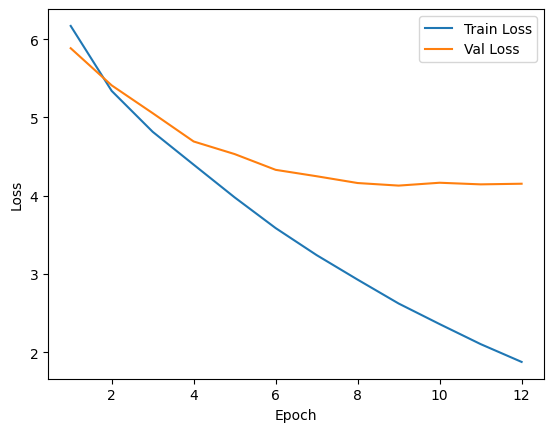

In [182]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses)+1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

## 4. Evaluation (BLEU, ROUGE, Perplexity):

In [22]:
!pip install sacrebleu
!pip install rouge 

In [29]:
import sacrebleu
from rouge import Rouge

def translate_batch(model, loader, sp_src, sp_tgt, device, max_len=128):
    model.eval()
    refs, hyps = [], []
    sos_id, eos_id = 1, 2

    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(device)

            for ref_ids in tgt.cpu().tolist():
                refs.append(sp_tgt.decode_ids(ref_ids[1:-1]).strip())

            batch_size = src.size(0)
            
            dec_input = torch.full(
                (batch_size, 1),
                fill_value=sos_id,
                dtype=torch.long,
                device=device
            )

            for _ in range(max_len - 1):
                
                logits = model(src, dec_input)
               
                next_token_logits = logits[:, -1, :]        
                next_tokens = next_token_logits.argmax(-1) 
   
                dec_input = torch.cat(
                    [dec_input, next_tokens.unsqueeze(1)],
                    dim=1
                )

                if (next_tokens == eos_id).all():
                    break

            
            for seq in dec_input.cpu().tolist():
                if eos_id in seq:
                    seq = seq[: seq.index(eos_id)]
                hyp_ids = seq[1:]  
                hyps.append(sp_tgt.decode_ids(hyp_ids).strip())

    return refs, hyps


transformer.load_state_dict(torch.load('best_transformer.pt'))
refs, hyps = translate_batch(transformer, test_loader, sp_en, sp_ur, device)

pairs = [(h, r) for h, r in zip(hyps, refs) if h and r]
hyps_f, refs_f = zip(*pairs)

# Computing BLEU
bleu = sacrebleu.corpus_bleu(list(hyps_f), [list(refs_f)])
print("BLEU:", bleu.score)

# Computing ROUGE
rouge = Rouge()
rouge_scores = rouge.get_scores(list(hyps_f), list(refs_f), avg=True)
print("ROUGE:", rouge_scores)

# Perplexity
def perplexity(model, loader, crit, device):
    loss = eval_epoch(model, loader, crit, device)
    return torch.exp(torch.tensor(loss))

print("Transformer Perplexity:", perplexity(transformer, test_loader, crit, device))


/tmp/ipykernel_31/1378941197.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transformer.load_state_dict(torch.load('best_transformer.pt'))


BLEU: 0.929091533307632
ROUGE: {'rouge-1': {'r': 0.322761657242058, 'p': 0.3030336550435393, 'f': 0.3046248400139588}, 'rouge-2': {'r': 0.06530680964588574, 'p': 0.06106835829981618, 'f': 0.06140184963264858}, 'rouge-l': {'r': 0.28559675939742823, 'p': 0.2670119232092071, 'f': 0.2688358249614572}}


Transformer Perplexity: tensor(86.9357)


## 5. Attention Visualization:

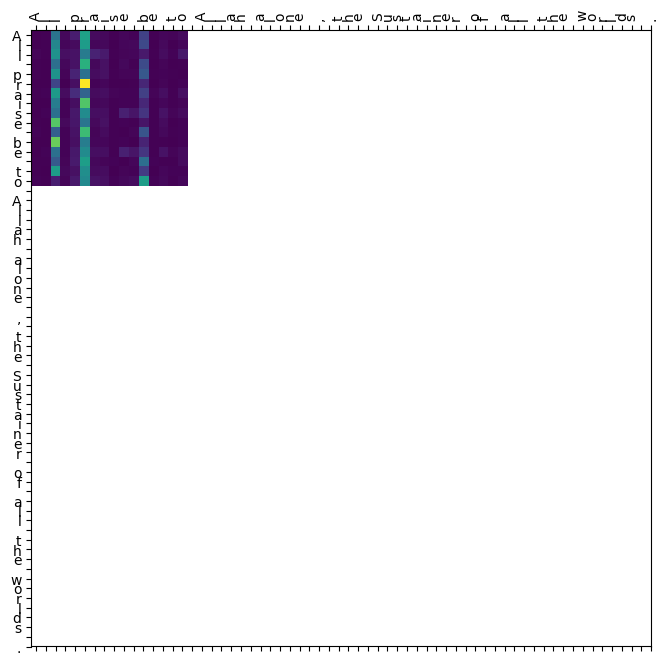

In [34]:
import torch
import matplotlib.pyplot as plt

def plot_attention(attn_weights, src_tokens, head=0):
   
    mat = attn_weights[head].detach().cpu()
    fig, ax = plt.subplots(figsize=(8,8))
    ax.matshow(mat, aspect='auto')
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=90)
    ax.set_yticklabels(src_tokens)
    plt.show()


sample = train_loader.dataset[0]         
sample_src = sample['src'].unsqueeze(0).to(device)  

src_emb = transformer.pos_enc(
    transformer.src_tok(sample_src).transpose(0,1)
)  

attn_layer = transformer.transformer.encoder.layers[0].self_attn
attn_out, attn_weights = attn_layer(
    src_emb, src_emb, src_emb,
    need_weights=True,
    average_attn_weights=False
)

attn_weights = attn_weights[0]

src_tokens = sp_en.decode_ids(sample_src[0].cpu().tolist())

plot_attention(attn_weights, src_tokens, head=0)


## Deploy:

In [35]:
!pip install pyngrok
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 18.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 103.9 MB/s eta 0:00:0000:01


In [61]:
%%writefile streamlit_app1.py

import streamlit as st
import torch
import math
from torch import nn
import sentencepiece as spm

# Loading SentencePiece models
sp_en = spm.SentencePieceProcessor(model_file='spm_en.model')
sp_ur = spm.SentencePieceProcessor(model_file='spm_ur.model')

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1)]
        return x

class TransformerMT(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=512, nhead=8,
                 num_layers=6, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.src_tok = nn.Embedding(src_vocab, d_model)
        self.tgt_tok = nn.Embedding(tgt_vocab, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model, nhead, num_layers, num_layers,
            dim_feedforward, dropout
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab)

    def forward(self, src, tgt):
        src_emb = self.pos_enc(self.src_tok(src).transpose(0, 1))
        tgt_emb = self.pos_enc(self.tgt_tok(tgt).transpose(0, 1))

        tgt_seq_len = tgt_emb.size(0)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            tgt_seq_len,
            device=src.device,
            dtype=tgt_emb.dtype
        )

        out = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask
        )
        
        return self.fc_out(out).transpose(0, 1)


@st.cache_resource

def load_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TransformerMT(
        src_vocab=sp_en.get_piece_size(),
        tgt_vocab=sp_ur.get_piece_size(),
        d_model=512, nhead=8, num_layers=6,
        dim_feedforward=2048, dropout=0.1
    ).to(device)
    model.load_state_dict(torch.load('/kaggle/working/best_transformer.pt', map_location=device))
    model.eval()
    return model, device

model, device = load_model()

if 'history' not in st.session_state:
    st.session_state.history = []

st.title("English → Urdu Translator")

with st.form("translate_form", clear_on_submit=True):
    user_input = st.text_input(
        label="Enter English text:",
        key="input",
        label_visibility="visible",
        placeholder="Type here..."
    )
    submit = st.form_submit_button("Translate")

if submit and user_input:
    
    ids = sp_en.encode(user_input)
    src = torch.tensor([1] + ids + [2], dtype=torch.long).unsqueeze(0).to(device)

    # Greedy decode
    with torch.no_grad():
        dec_input = torch.tensor([[1]], device=device)
        for _ in range(128):
            logits = model(src, dec_input)
            next_id = logits[:, -1, :].argmax(-1)
            dec_input = torch.cat([dec_input, next_id.unsqueeze(1)], dim=1)
            if next_id.item() == 2:
                break
    ur_tokens = dec_input[0].cpu().tolist()[1:]
    if 2 in ur_tokens:
        ur_tokens = ur_tokens[:ur_tokens.index(2)]
    translation = sp_ur.decode_ids(ur_tokens)

    st.session_state.history.append((user_input, translation))

# Rendering conversation history
for en, ur in st.session_state.history:
    st.markdown(f"<div style='text-align: left; padding: 4px;'>{en}</div>", unsafe_allow_html=True)
    st.markdown(f"<div style='text-align: right; padding: 4px; direction: rtl;'>{ur}</div>", unsafe_allow_html=True)



Overwriting streamlit_app1.py


In [37]:
!ngrok authtoken 2jb86JKOHKjdCaoHKnPIeqPbJJ9_6Zrx6tHZQeLacbEwNFuCQ

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml                                


In [62]:
from pyngrok import ngrok

# Start a new ngrok tunnel
public_url = ngrok.connect(8000)

print("Ngrok public URL:", public_url)

Ngrok public URL: NgrokTunnel: "https://59b7-104-154-233-118.ngrok-free.app" -> "http://localhost:8000"


In [63]:
!streamlit run streamlit_app1.py --server.port 8000




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8000
  Network URL: http://172.19.2.2:8000
  External URL: http://104.154.233.118:8000

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/kaggle/working/streamlit_app1.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitr